# Advanced Macroeconomics
## Dynamic Programming & Reinforcement Learning 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from dynamic_programming.bellman_operator import BellmanOperator
from src.problem.opti_problem import CES

### Question 1 & 2

An agent has the opportunity to allocate her time between producing the consumption good C, and accumulating human capital H. Her intertemporal optimization problem is has follow:

$$\sum_{t=0}^{+\infty} \beta^t U(C_t)$$

subject to the following constraints: 
1. The production function, $\forall t, C_t = H_t^\alpha L_t$
2. The law of motion, $\forall t, H_{t+1} = (1-\delta)H_t + 1 - L_t$
3. The control domain, $\forall t, L_{t} \in [0,1]$

The human capital $H_t$ and the labour $L_t$ are respectively the state variable and the control variable. Assuming a CRRA utility, the recursive problem is given by:

$$V(H_t) = \max_{L_t \in [0,1]} \left[\frac{(H_t^\alpha L_t)^{1-\sigma}}{1-\sigma} + \beta V((1-\delta)H_t + 1 - L_t)\right]$$

where the value function V is not known and is to determine. Throughout the notebooks we will refer to the policy as the function, that given a state of human capital $H_t$ determines an associated quantity of labour $L_t$. Then, the next state of human capital $H_{t+1}$ is obtained from the law of motion.

In [2]:
# Grid
grid = np.linspace(1e-3, 5, 4000)

# Initial conditions and shocks
init_w = 0.5 * np.log(grid)

In [4]:
# Computation of the value function
recursive_solver = BellmanOperator(init_w=init_w, grid=grid)
recursive_solver.solve_optgrowth()

Recursive Solver:  22%|██▏       | 111/500 [00:19<01:08,  5.69iter/s, Error=9.36e-5] 


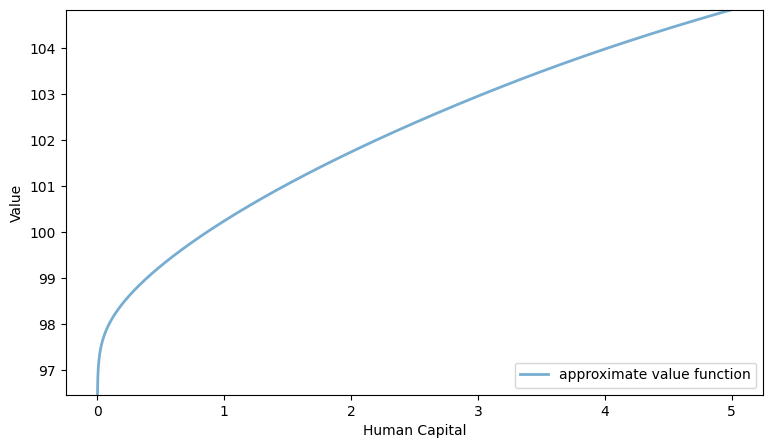

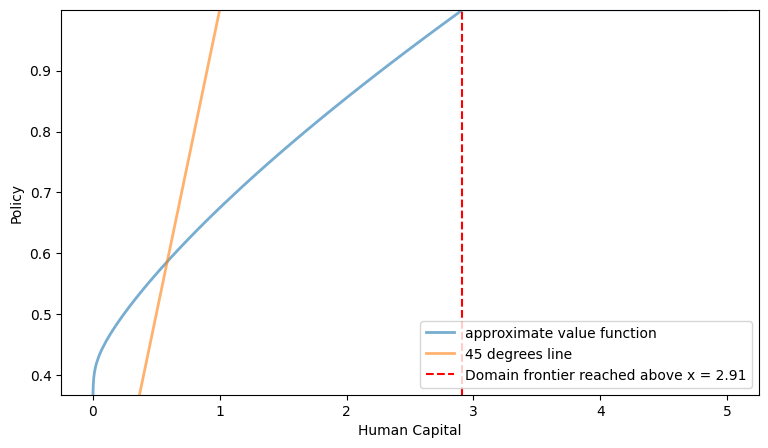

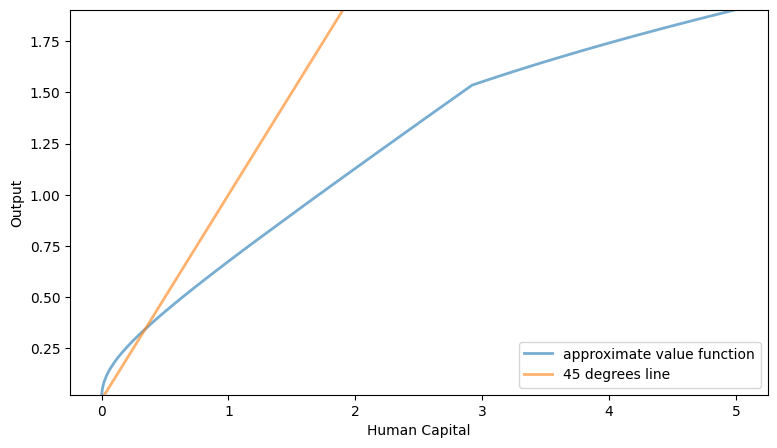

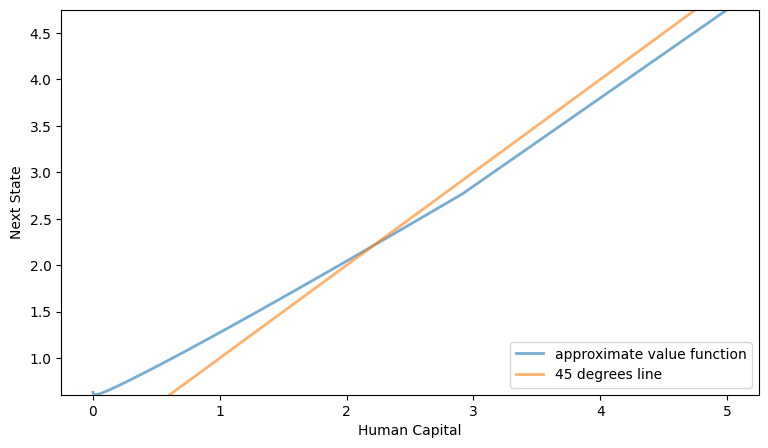

In [5]:
recursive_solver.plot_results("Value")
recursive_solver.plot_results("Policy", control_bound=(0, 1 - 1e-3))
recursive_solver.plot_results("Output")
recursive_solver.plot_results("Next State")

In [6]:
recursive_results = recursive_solver.get_results()

The recursive methods is valid when the optimal path of control lies in the interior of it's domain. Thus above the red doted line we are not sure about our approximation of the value function.

### Question 3 & 4

In [7]:
from src.dynamic_programming.epsilon_greedy import EpsilonGreedy
from src.utils.plot import compare_approx

As we know the law of motion of the model and the reward, it is not optimal to use an espilon-greedy search

In [30]:
greedy_solver = EpsilonGreedy(init_w=init_w, grid=grid, epsilon=0.0)
greedy_solver.solve_optgrowth(max_iter=200)

Greedy Solver:   0%|          | 0/200 [00:00<?, ?iter/s]

109


Greedy Solver:   0%|          | 1/200 [00:01<04:32,  1.37s/iter, Error=0.682]

50


Greedy Solver:   1%|          | 2/200 [00:02<04:11,  1.27s/iter, Error=0.682]

...

Greedy Solver:   6%|▌         | 11/200 [00:10<02:28,  1.27iter/s, Error=0.00386]

3


Greedy Solver:   6%|▌         | 12/200 [00:11<02:20,  1.34iter/s, Error=0.00386]

1


Greedy Solver:   6%|▋         | 13/200 [00:11<02:51,  1.09iter/s, Error=4.29e-5]


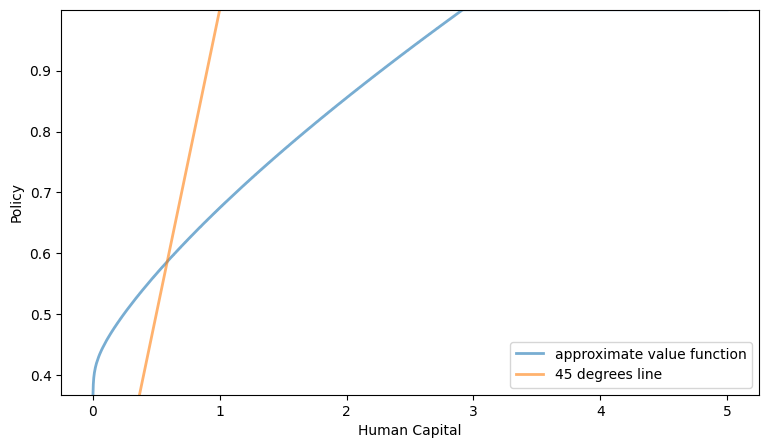

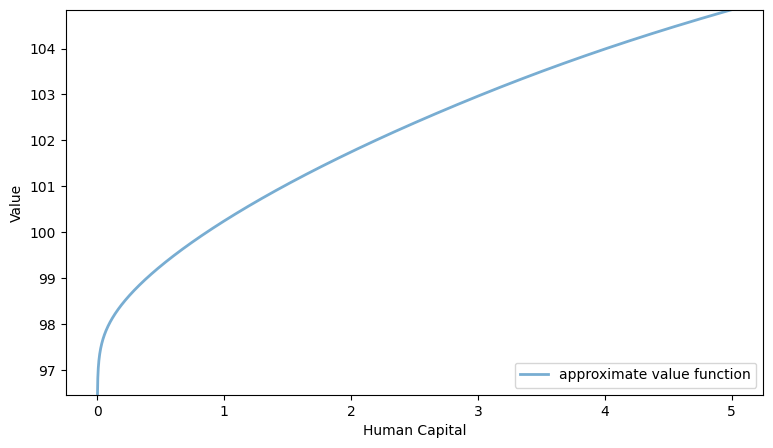

In [31]:
greedy_solver.plot_results("Policy")
greedy_solver.plot_results("Value")

In [32]:
greedy_history = np.matrix(greedy_solver.pol_history[1:]).T
greedy_results = greedy_solver.get_results()
explore_history = greedy_solver.explore_history

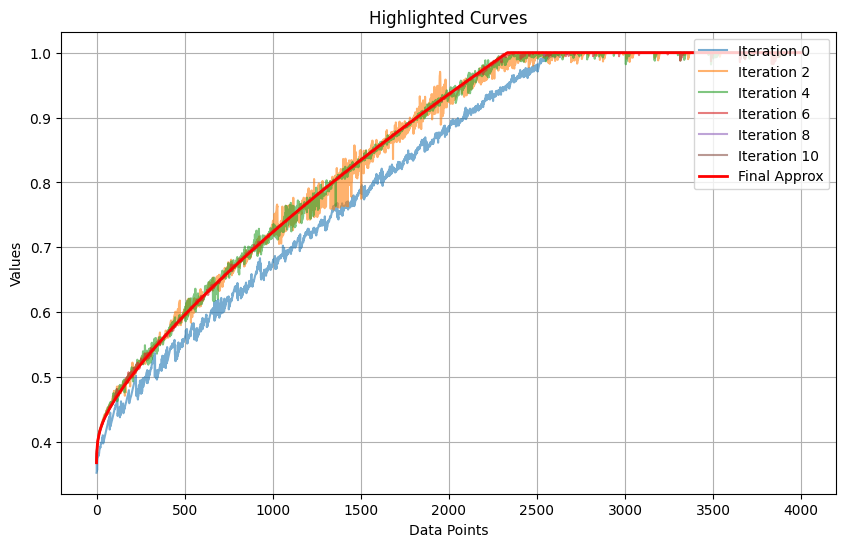

In [33]:
plt.figure(figsize=(10, 6))
for i in range(greedy_history.shape[1]):
    if i == greedy_history.shape[1] - 1:
        plt.plot(greedy_history[:, i], label="Final Approx", linewidth=2, color="red")
    elif i % 2 == 0:
        plt.plot(greedy_history[:, i], label=f"Iteration {i}", alpha=0.6)  # Standard
    

plt.title("Highlighted Curves")
plt.xlabel("Data Points")
plt.ylabel("Values")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

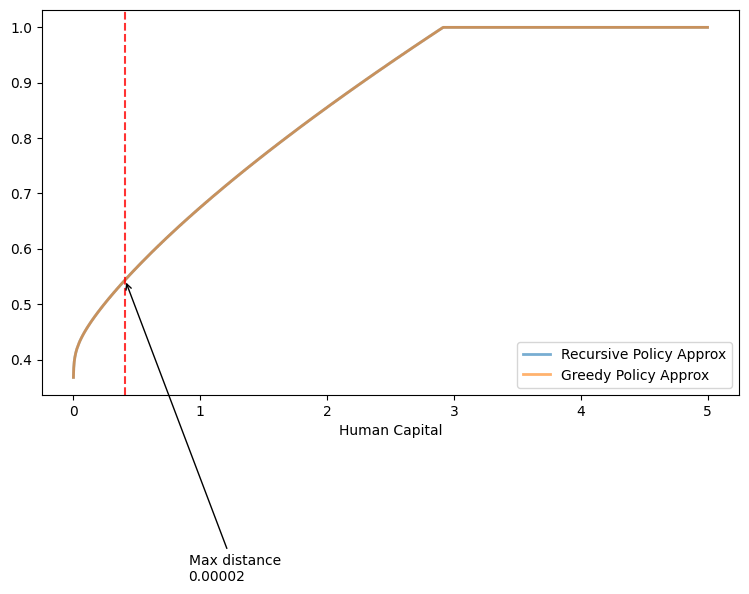

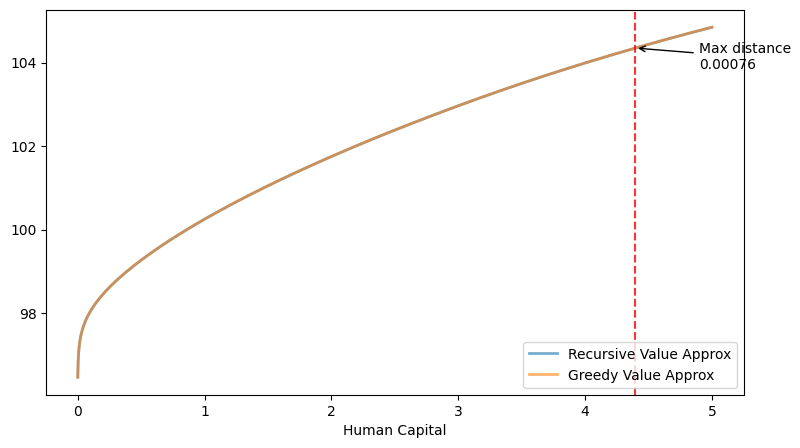

In [34]:
compare_approx(
    grid,
    recursive_results["Policy"],
    greedy_results["Policy"],
    "Recursive Policy Approx",
    "Greedy Policy Approx",
)

compare_approx(
    grid,
    recursive_results["Value"],
    greedy_results["Value"],
    "Recursive Value Approx",
    "Greedy Value Approx",
)

The two methods of estimation yield close approximation of the value and the policy function. 

### Optionnal Question

The initial problem is:

$$\sum_{t=0}^{+\infty} \beta^t \frac{C_t^{1-\sigma}}{1-\sigma}$$

subject to the following constraints: 
1. The production function, $\forall t, C_t = H_t^\alpha L_t$
2. The state transition equation, $\forall t, H_{t+1} = (1-\delta)H_t + 1 - L_t$
3. The control domain, $\forall t, L_{t} \in [0,1]$

The lagrangian is given by:

$$\mathcal{L}=\sum_{t=0}^{+\infty} \beta^t \frac{(H_t^\alpha L_t)^{1-\sigma}}{1-\sigma} + \sum_{t=0}^{+\infty}\lambda_t\left[(1-\delta)H_t + 1 - L_t -H_{t+1}\right]$$

Using the F.O.C. condition we get:

1. w.r.t. to $L_t$: $\quad$ $\beta^tC_t^{-\sigma}H_t^\alpha=\lambda_t$
2. w.r.t. to $H_t$: $\quad$ $\beta^tC_t^{-\sigma}\alpha H_t^{\alpha-1}L_t + (1-\delta)\lambda_t - \lambda_{t-1}=0$

Using 1. in 2. gives the euler equation:

$$C_t^{-\sigma}H_t^\alpha=\beta C_{t+1}^{-\sigma}\left[\alpha H_{t+1}^{\alpha - 1}L_{t+1} + (1-\delta)H_{t+1}^\alpha\right]$$

To approximate the value function with a Neural Network, we will define and use a loss function as a weighted sum of the following quantities:

1. The law of motion: $||H_{t+1} - (1-\delta)H_t + 1 - L_t||$
2. The euler equation: $||C_t^{-\sigma}H_t^\alpha - \beta C_{t+1}^{-\sigma}\left[\alpha H_{t+1}^{\alpha - 1}L_{t+1} + (1-\delta)H_{t+1}^\alpha\right]||$
3. The initial condition: $||\hat{H}_0 - H_0||$

The Network Network take as entry a time $t$ and output a state $H_t$ and a control $L_t$. The output layer utilizes two distinct activation functions: a Softplus for $H_t$ and a Sigmoid for  $L_t$. It ensures that $H_t > 0$ and $0 < L_t < 1$. One drawdown is that it does not allow for $L_t = 1$. 

In [1]:
from src.neural_network.nn_method import *

In [2]:
grid_data = GridData(max_T=250, batch_size=50)
train_loader = grid_data.loader
num_epochs = 1001

In [14]:
q_hat = NN(h_0=8, layers=4, dim_hidden=128)
learning_rate = 1e-3
optimizer = torch.optim.Adam(q_hat.parameters(), lr=learning_rate)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)

In [15]:
print(q_hat)

NN(
  (q): Sequential(
    (0): Linear(in_features=1, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): Tanh()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): Tanh()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)


In [22]:
for epoch in range(num_epochs):
    for time in train_loader:
        loss, loss_1, loss_2, loss_3 = q_hat.compute_loss(time, weight=np.array([0.4, 0.8, 0.001]))

        optimizer.zero_grad()
        loss.backward()

        optimizer.step()
    scheduler.step()

    if epoch == 0:
        print(
            "epoch",
            ",",
            "loss",
            ",",
            "loss_motion",
            ",",
            "loss_euler",
            ",",
            "loss_initial",
            ",",
            "lr_rate",
        )
    if epoch % 100 == 0:
        print(
            epoch,
            ",",
            "{:.2e}".format(loss.detach().numpy()),
            ",",
            "{:.2e}".format(loss_1.detach().numpy()),
            ",",
            "{:.2e}".format(loss_2.detach().numpy()),
            ",",
            "{:.2e}".format(loss_3.detach().numpy()),
            ",",
            "{:.2e}".format(get_lr(optimizer)),
        )

epoch , loss , loss_motion , loss_euler , loss_initial , lr_rate
0 , 5.27e-04 , 4.57e-05 , 6.34e-04 , 1.64e-03 , 1.15e-05
100 , 3.20e-04 , 3.71e-05 , 3.78e-04 , 2.04e-03 , 9.22e-06
200 , 4.22e-04 , 4.45e-05 , 5.03e-04 , 2.08e-03 , 7.38e-06
300 , 2.99e-04 , 3.45e-05 , 3.54e-04 , 2.12e-03 , 5.90e-06
400 , 4.36e-04 , 4.67e-05 , 5.19e-04 , 2.15e-03 , 4.72e-06
500 , 4.91e-04 , 4.75e-05 , 5.87e-04 , 2.12e-03 , 3.78e-06
600 , 4.98e-04 , 5.37e-05 , 5.93e-04 , 2.13e-03 , 3.02e-06
700 , 2.16e-04 , 2.69e-05 , 2.54e-04 , 2.12e-03 , 2.42e-06
800 , 7.27e-04 , 8.01e-05 , 8.67e-04 , 2.08e-03 , 1.93e-06
900 , 3.55e-04 , 3.86e-05 , 4.22e-04 , 2.13e-03 , 1.55e-06
1000 , 9.00e-05 , 1.06e-05 , 1.04e-04 , 2.13e-03 , 1.24e-06


In [23]:
time_test = grid_data.time_range
h_hat_path = q_hat(time_test)[:, [0]].detach()
l_hat_path = q_hat(time_test)[:, [1]].detach()


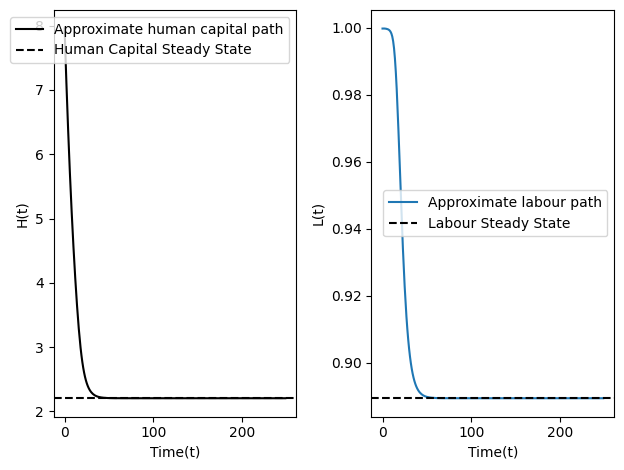

In [24]:
plt.subplot(1, 2, 1)

plt.plot(time_test, h_hat_path, color="k", label=r"Approximate human capital path")
plt.ylabel(r"H(t)")
plt.axhline(y=q_hat.ces.steady_h, linestyle="--", color="k", label="Human Capital Steady State")
plt.xlabel(r"Time(t)")
plt.legend(loc="best")

plt.subplot(1, 2, 2)
plt.plot(time_test, l_hat_path, label=r"Approximate labour path")
plt.ylabel(r"L(t)")
plt.axhline(
    y=q_hat.ces.steady_l, linestyle="--", color="k", label="Labour Steady State"
)
plt.xlabel(r"Time(t)")
plt.tight_layout()
plt.legend(loc="best")
plt.tight_layout()
plt.show()

Depending on the initial level of human capital, we may observe trajectories where labor either fails to converge or converges slowly to the steady state. This behavior may stem from the optimization problem not being strictly convex, leading to convergence toward a suboptimal solution, or simply requiring more time to reach convergence. Additionally, exploring different functional forms of the activation function can provide insights into their impact on convergence. For example, the ReLU activation function appears to perform worse than the Tanh activation function under the same hyperparameters.

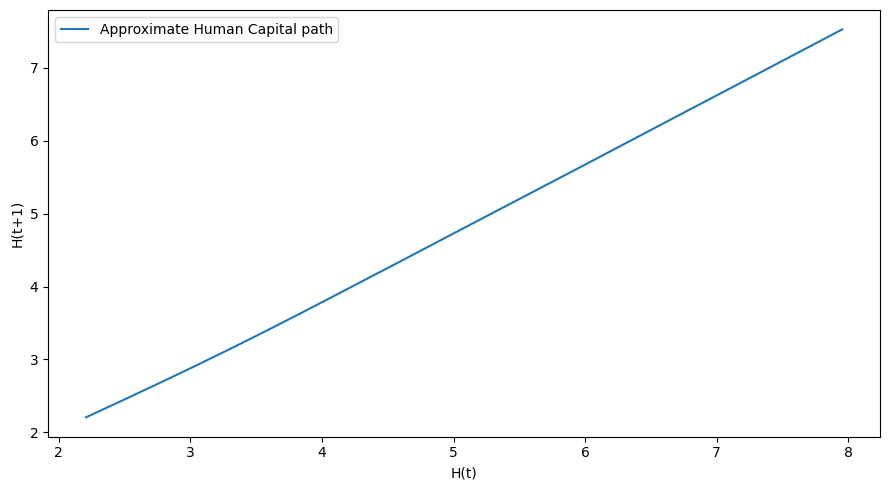

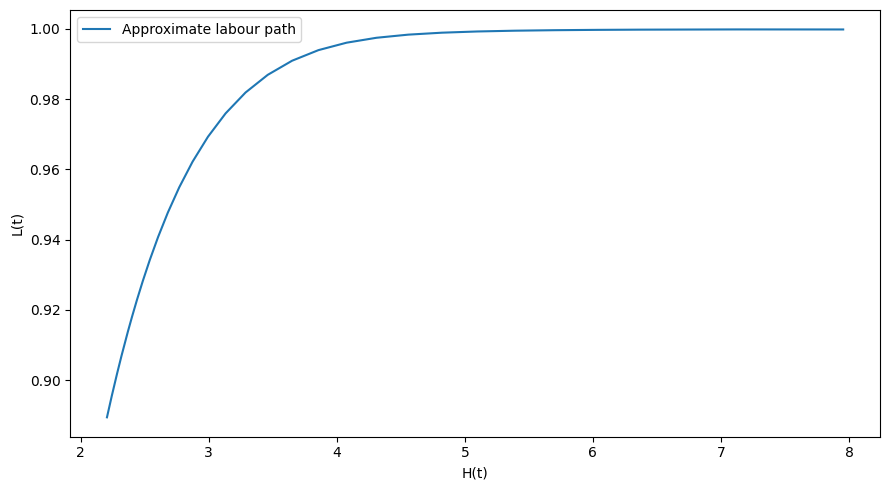

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_hat_path[:-1], h_hat_path[1:], label=r"Approximate Human Capital path")
plt.ylabel(r"H(t+1)")
plt.xlabel(r"H(t)")
plt.tight_layout()
plt.legend(loc="best")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(h_hat_path, l_hat_path, label=r"Approximate labour path")
plt.ylabel(r"L(t)")
plt.xlabel(r"H(t)")
plt.tight_layout()
plt.legend(loc="best")
plt.tight_layout()
plt.show()